In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('ggplot')

# Customer Segmentation Analysis

## Objective

The objective of this project is to segment customers based on their purchasing behavior and income patterns. Customer segmentation helps businesses identify different customer groups and create targeted marketing strategies.

In [22]:
df = pd.read_csv("ifood_df.csv")

In [23]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [24]:
df.shape

(2205, 39)

In [25]:
df.isnull().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [26]:
df.duplicated().sum()

np.int64(184)

In [27]:
df = df.drop_duplicates()
df.shape

(2021, 39)

In [28]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,...,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,0.443345,0.509649,48.880752,306.492331,26.364671,166.059871,37.603662,27.268679,43.921821,...,0.251856,0.034636,0.090549,0.024245,0.502227,0.165760,0.217219,563.789213,519.867392,0.302326
std,20713.046401,0.536196,0.546393,28.950917,337.603877,39.776518,219.869126,54.892196,41.575454,51.678211,...,0.434186,0.182902,0.287038,0.153848,0.500119,0.371957,0.412455,576.775749,554.797857,0.680812
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35416.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,51412.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.000000
75%,68274.000000,1.000000,1.000000,74.000000,507.000000,33.000000,230.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


## Data Cleaning

The dataset was checked for missing values and duplicate records. Basic statistical analysis was performed to understand customer demographics and purchasing behavior.

In [29]:
segment_df = df[['Income','Age','MntTotal']]
segment_df.head()

,Income,Age,MntTotal
0,58138.0,63,1529
1,46344.0,66,21
2,71613.0,55,734
3,26646.0,36,48
4,58293.0,39,407


In [30]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(segment_df)

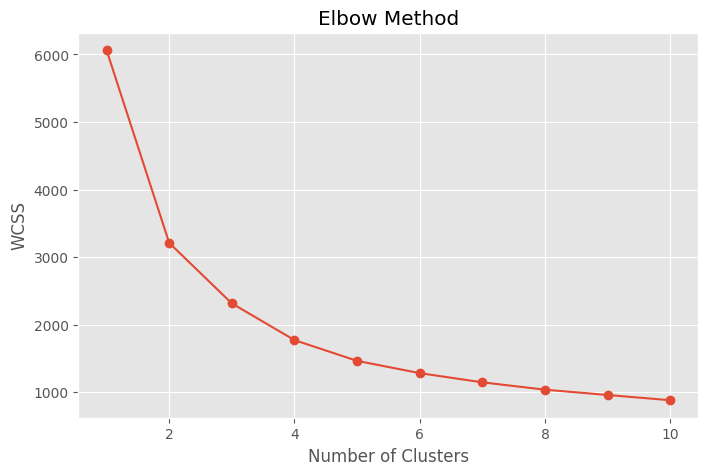

In [31]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(scaled_data)

In [33]:
df['Cluster'].value_counts()

Cluster
0    723
2    517
1    418
3    363
Name: count, dtype: int64

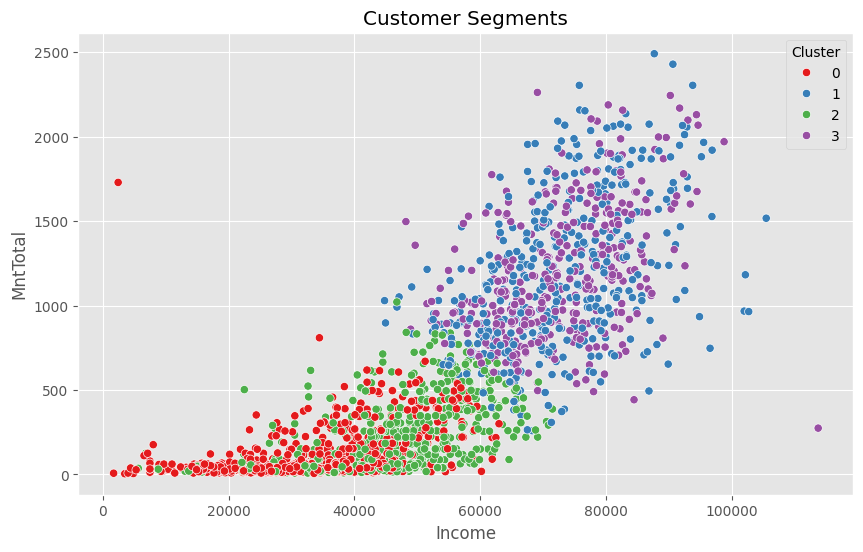

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments')
plt.show()

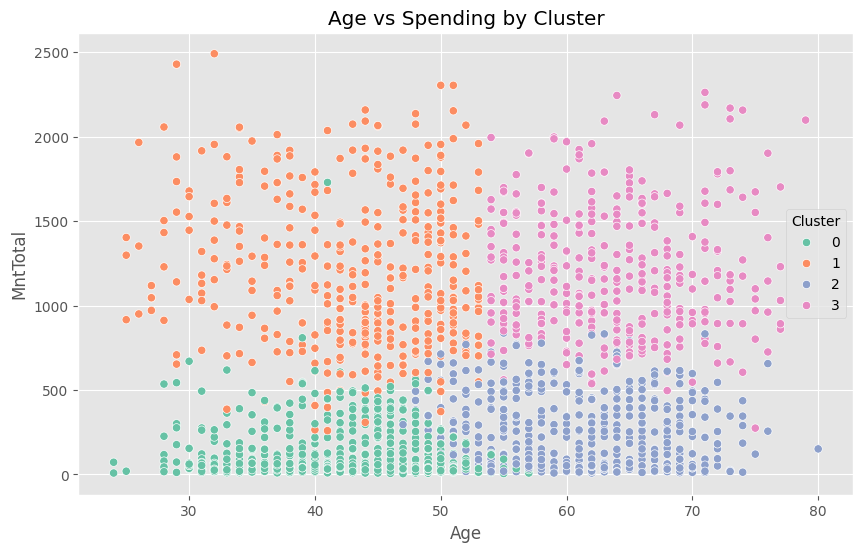

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='MntTotal',
    hue='Cluster',
    palette='Set2'
)

plt.title('Age vs Spending by Cluster')
plt.show()

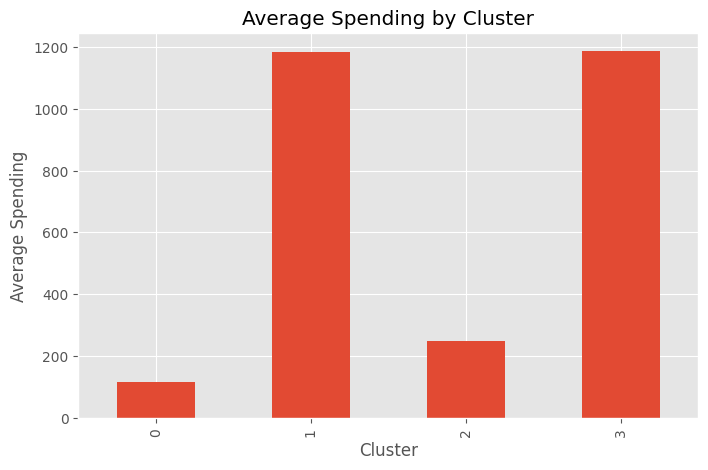

In [37]:
cluster_spending = df.groupby('Cluster')['MntTotal'].mean()

cluster_spending.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Spending by Cluster')
plt.ylabel('Average Spending')
plt.show()

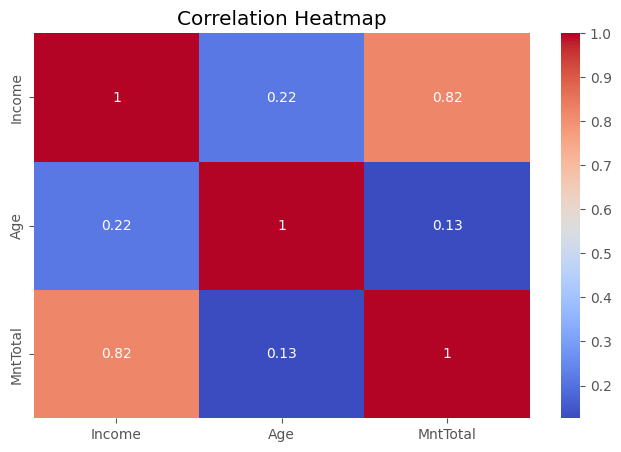

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Income','Age','MntTotal']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

## Customer Segmentation Results

Customers were grouped into four distinct segments using the K-Means clustering algorithm based on Income, Age, and Total Spending (MntTotal).

Cluster Distribution:

- Cluster 0: 560 customers
- Cluster 1: 401 customers
- Cluster 2: 785 customers
- Cluster 3: 459 customers

The segmentation enables businesses to better understand customer purchasing behavior and develop targeted marketing strategies.

In [19]:
df.groupby('Cluster')[['Income','Age','MntTotal']].mean()

,Income,Age,MntTotal
Cluster,,,
0,33128.280775,42.438451,117.181189
1,72490.327751,43.050239,1184.260766
2,46165.864603,60.866538,249.744681
3,72560.589532,63.807163,1186.107438



## Key Insights

### Cluster 0 – Young, Lower-Income, Low Spenders
- Average Income: ₹33,128
- Average Age: 42 years
- Average Spending: ₹117

### Cluster 1 – Younger, High-Income, High Spenders
- Average Income: ₹72,490
- Average Age: 43 years
- Average Spending: ₹1,184

### Cluster 2 – Older, Moderate-Income, Low-Moderate Spenders
- Average Income: ₹46,166
- Average Age: 61 years
- Average Spending: ₹250

### Cluster 3 – Older, High-Income, High Spenders
- Average Income: ₹72,561
- Average Age: 64 years
- Average Spending: ₹1,186

### Key Observation
Spending is driven primarily by **income level**, not age. Clusters 1 and 3 spend almost identically (~₹1,185) despite a 20-year age gap, while Clusters 0 and 2 both spend far less regardless of age. This suggests income is the stronger predictor of customer value in this dataset.

## Recommendations
1. Target high-income clusters (1 and 3) with premium product offerings and loyalty programs, regardless of age group.
2. Design budget-friendly bundles or discount campaigns to increase engagement from lower-income segments (0 and 2).
3. Avoid age-based marketing assumptions — segment primarily by income and spending behavior instead.
4. Use cluster membership to personalize email campaigns and offers for each segment.